In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
torch.manual_seed(123)
import torchvision
from torchvision.ops import box_convert, complete_box_iou_loss, box_iou
import math
from torch.utils.data import TensorDataset, DataLoader
import copy


### Load data and preprocessing

In [2]:
def normalize(train, val, test):
    train_tensors = train.tensors[0]  # Get the underlying tensor
    val_tensors = val.tensors[0]  
    test_tensors = test.tensors[0]  

    mean = train_tensors.mean()    # Mean per feature
    std  = train_tensors.std()     # Std per feature
    
    train_norm = (train_tensors - mean) / std 
    val_norm = (val_tensors - mean) / std 
    test_norm = (test_tensors - mean) / std 
    return TensorDataset(train_norm, train.tensors[1]), TensorDataset(val_norm, val.tensors[1]), TensorDataset(test_norm, test.tensors[1])


In [3]:
def load_data():
    train = torch.load('data/localization_train.pt', weights_only=False)
    val = torch.load('data/localization_val.pt', weights_only=False)
    test = torch.load('data/localization_test.pt', weights_only=False)
    norm_train, norm_val, norm_test = normalize(train, val, test)
    return train, val, test, norm_train, norm_val, norm_test

train, val, test, norm_train, norm_val, norm_test = load_data()
print(f'Train size: {len(train)}')
print(f'Val size: {len(val)}')
print(f'Test size: {len(test)}')  


labels = train.tensors[1]
# første indeks i label
class_ids = labels[:, 0]
digits = labels[:, -1].long() 

total = len(labels)
no_object = (class_ids == 0).sum().item()
has_object = (class_ids != 0).sum().item()

digit_counts = torch.bincount(digits, minlength=10)
for i in range(10):
    percentage = (digit_counts[i].item() / total) * 100 if total > 0 else 0
    print(f"Digit: {i}: {percentage:.2f}%")

print(f"Color-range: {int(train.tensors[0].min().item())} to {int(train.tensors[0].max().item())}")
print(f"Total samples: {total}")
print(f"No object: {no_object}")
print(f"Has object: {has_object}")
print(f"Image shape: {train.tensors[0].shape[1:]}")
print("Label:", train.tensors[1][0])





Train size: 59400
Val size: 6600
Test size: 11000
Digit: 0: 9.00%
Digit: 1: 19.32%
Digit: 2: 9.03%
Digit: 3: 9.30%
Digit: 4: 8.83%
Digit: 5: 8.23%
Digit: 6: 8.94%
Digit: 7: 9.50%
Digit: 8: 8.84%
Digit: 9: 9.02%
Color-range: 0 to 1
Total samples: 59400
No object: 5400
Has object: 54000
Image shape: torch.Size([1, 48, 60])
Label: tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])


## Data exploration

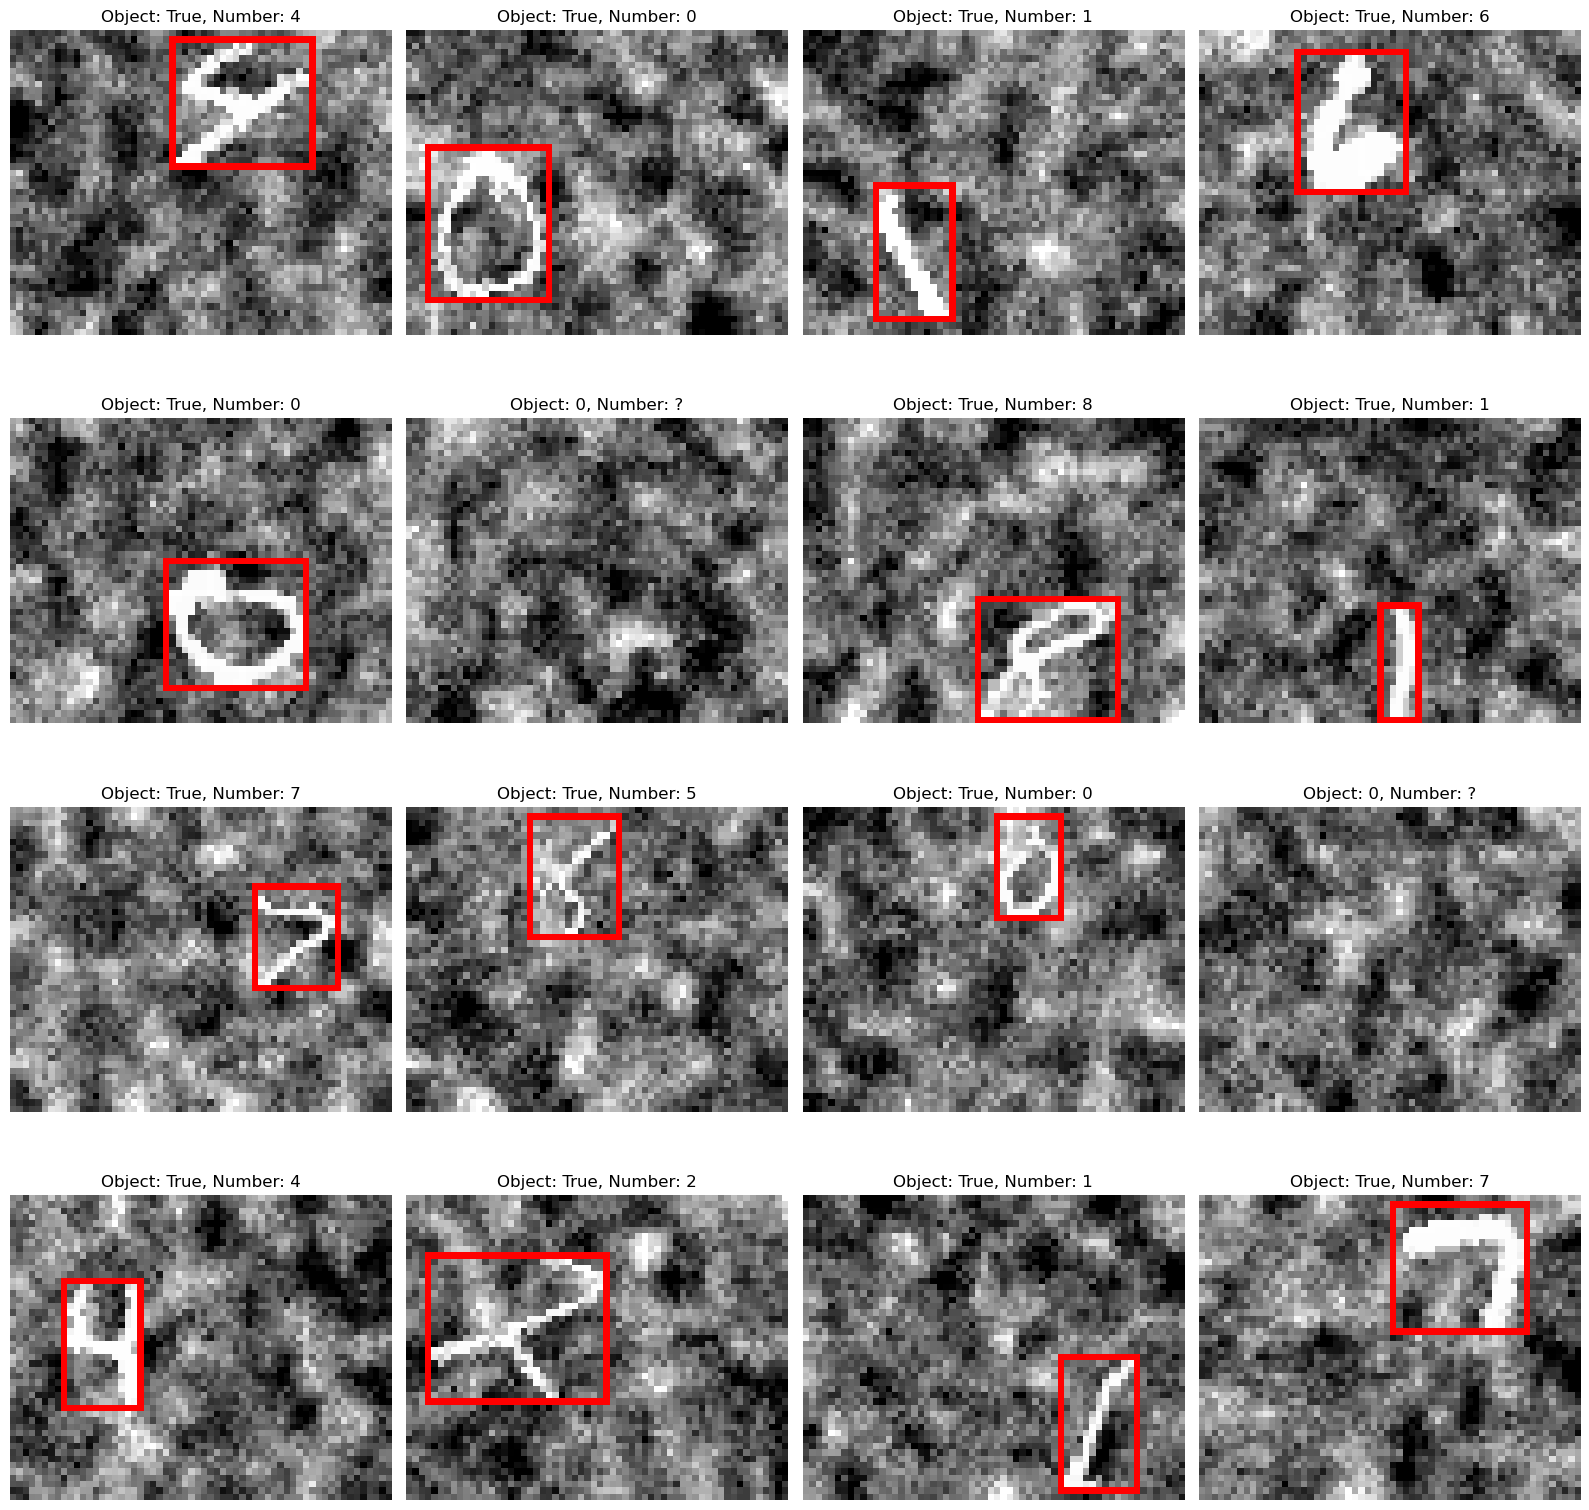

In [4]:
def get_drawn_image(ds, i=0):
    img = ds.tensors[0][i]         
    y   = ds.tensors[1][i].float()  
    H, W = img.shape[-2], img.shape[-1]


    box = y[1:5].unsqueeze(0)              
    box_xyxy = box_convert(box, "cxcywh", "xyxy")  

    # Scale to pixels
    box_xyxy = box_xyxy * torch.tensor([W, H, W, H], dtype=torch.float32)

    # Makes image clearer for preview 
    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3, 1, 1)

    if int(y[0].item()) == 0:
        return img_u8.permute(1,2,0).numpy(), int(y[0].item()), '?'

    drawn = torchvision.utils.draw_bounding_boxes(img_u8, box_xyxy, colors="red", width=1)
    return drawn.permute(1,2,0).numpy(), bool(y[0].item()), int(y[-1].item())


def show_samples(ds, n=7):
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()  

    for i in range(n):
        img, cls, number = get_drawn_image(ds, i)
        axes[i].imshow(img)
        axes[i].set_title(f"Object: {cls}, Number: {number}")
        axes[i].axis("off")

    # Hide empty subplot if n does not fill the grid
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(f"figures/localization_exploration.png", bbox_inches="tight")
    plt.show()

show_samples(train, 16)

## Model definition

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device {device}.")

num_classes = int(train.tensors[1][:, 5].max().item()) + 1
print(f"{num_classes} classes")

class Net(nn.Module):
    def __init__(self, input_channels=1, input_size=(48, 60), conv_configs=None,
                 fc_hidden_sizes=None, num_classes=15, pool_size=2, dropout=0.0):
        super().__init__()
        if conv_configs is None:    conv_configs = [(6, 5), (16, 5)]
        if fc_hidden_sizes is None: fc_hidden_sizes = [120, 84]

        self.pool = nn.MaxPool2d(pool_size, pool_size)
        self.dropout = nn.Dropout(dropout)

        self.convs = nn.ModuleList()
        in_ch = input_channels
        for out_ch, k in conv_configs:
            self.convs.append(nn.Conv2d(in_ch, out_ch, k))
            in_ch = out_ch

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, *input_size)
            for conv in self.convs:
                dummy = self.pool(F.relu(conv(dummy)))
            flat_size = dummy.view(1, -1).shape[1]

        self.fcs = nn.ModuleList()
        in_feat = flat_size
        for hidden in fc_hidden_sizes:
            self.fcs.append(nn.Linear(in_feat, hidden))
            in_feat = hidden
        self.out = nn.Linear(in_feat, num_classes)

    def forward(self, x):
        for conv in self.convs:
            x = self.pool(F.relu(conv(x)))
        x = x.view(x.size(0), -1)
        for fc in self.fcs:
            x = self.dropout(F.relu(fc(x)))
        return self.out(x)

net_light = Net(conv_configs=[(4, 3), (8, 3)],           fc_hidden_sizes=[64],            num_classes=15)
net_deep  = Net(conv_configs=[(32, 3), (64, 3), (128, 3)], fc_hidden_sizes=[512, 256],     dropout=0.5)
net_wide  = Net(conv_configs=[(32, 5), (64, 5)],          fc_hidden_sizes=[1024, 512, 256], dropout=0.3)

Training on device cuda.
10 classes


## Localization


In [6]:
def localization_loss(y_pred, y_true):
    obj_mask = y_true[:, 0] > 0.5 

    # LA: detection (all samples)
    det_loss = F.binary_cross_entropy_with_logits(y_pred[:, 0], y_true[:, 0])

    if obj_mask.any():
        # LB: bbox only for positives
        box_loss = F.mse_loss(y_pred[obj_mask, 1:5], y_true[obj_mask, 1:5])

        # LC: class only for positives
        target = y_true[obj_mask, 5].long()         
        logits = y_pred[obj_mask, 5:]               

        C = logits.shape[1]
        if target.min() < 0 or target.max() >= C:
            raise ValueError(f"class target out of range: min={target.min().item()} max={target.max().item()} C={C}")

        cls_loss = F.cross_entropy(logits, target)
    else:
        box_loss = y_pred.new_tensor(0.0)
        cls_loss = y_pred.new_tensor(0.0)

    return det_loss + box_loss + cls_loss

### Predictions

In [33]:
def predict(net, dataloader):
    net.eval()

    all_preds = []
    correct = 0
    total = 0
    total_iou = 0.0
    iou_count = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = net(inputs)
            all_preds.append(outputs.cpu())

            pc_true = targets[:, 0] > 0.5
            detected = torch.sigmoid(outputs[:, 0]) > 0.5

            class_pred = torch.argmax(outputs[:, 5:], dim=1)
            class_true = targets[:, 5].long()
            pc_pred = torch.sigmoid(outputs[:, 0])


            total += pc_true.sum().item()
            if pc_true.any():
                idx = torch.where(pc_true)[0]
                correct += (detected[idx] & (class_pred[idx] == class_true[idx])).sum().item()

                box_pred = outputs[:, 1:5].clone()
                box_true = targets[:, 1:5].clone()

                box_pred[:, 2:] = box_pred[:, 2:].abs().clamp(min=1e-6)
                box_true[:, 2:] = box_true[:, 2:].abs().clamp(min=1e-6)

                pred_xyxy = box_convert(box_pred[idx], "cxcywh", "xyxy").clamp(0.0, 1.0)
                true_xyxy = box_convert(box_true[idx], "cxcywh", "xyxy").clamp(0.0, 1.0)

                ious = box_iou(pred_xyxy, true_xyxy).diag()
                total_iou += ious.sum().item()
                iou_count += ious.numel()

    accuracy = correct / total if total > 0 else 0.0
    mean_iou = total_iou / iou_count if iou_count > 0 else 0.0
    performance = 0.5 * (accuracy + mean_iou)


    return torch.cat(all_preds, dim=0), accuracy, mean_iou, performance


### Training

In [8]:
def train_model(net, num_epochs=20, patience=5, lr=0.01, weight_decay=0.0):
    net = net.to(device)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    trainloader = torch.utils.data.DataLoader(norm_train, batch_size=64, shuffle=True, num_workers=0)
    val_loader  = torch.utils.data.DataLoader(norm_val,   batch_size=64, shuffle=False, num_workers=0)

    best_perf = -float("inf")
    best_weights = copy.deepcopy(net.state_dict())
    epochs_no_improve = 0
    history = []

    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = localization_loss(net(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        _, val_acc, val_iou, val_perf = predict(net, val_loader)
        print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_acc={val_acc:.4f} | val_iou={val_iou:.4f} | val_perf={val_perf:.4f}")
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "val_acc": val_acc, "val_iou": val_iou, "val_perf": val_perf})

        if val_perf > best_perf:
            best_perf, best_weights, epochs_no_improve = val_perf, copy.deepcopy(net.state_dict()), 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    net.load_state_dict(best_weights)
    return net, history, best_perf


param_grid = [
    {"lr": 0.01,  "weight_decay": 0.0},
    {"lr": 0.01,  "weight_decay": 1e-4},
    {"lr": 0.001, "weight_decay": 0.0},
    {"lr": 0.001, "weight_decay": 1e-4},
]

model_configs = {
    "light": dict(conv_configs=[(4, 3), (8, 3)],            fc_hidden_sizes=[64],             num_classes=15),
    "deep":  dict(conv_configs=[(32, 3), (64, 3), (128, 3)], fc_hidden_sizes=[512, 256],       dropout=0.5),
    "wide":  dict(conv_configs=[(32, 5), (64, 5)],           fc_hidden_sizes=[1024, 512, 256], dropout=0.3),
}

all_results = {} 

for model_name, cfg in model_configs.items():
    for params in param_grid:
        run_key = (model_name, params["lr"], params["weight_decay"])
        print(f"\n=== {model_name} | lr={params['lr']} | wd={params['weight_decay']} ===")
        net = Net(**cfg)
        trained_net, history, best_perf = train_model(net, **params)
        all_results[run_key] = (trained_net, history, best_perf)
        print(f"Finished — best_perf={best_perf:.4f}")

best_key, (best_model, best_history, best_perf) = max(all_results.items(), key=lambda x: x[1][2])
best_name, best_lr, best_wd = best_key
print(f"\nBest run: model={best_name} | lr={best_lr} | wd={best_wd} | perf={best_perf:.4f}")


=== light | lr=0.01 | wd=0.0 ===
Epoch 01/20 | train_loss=2.3106 | val_acc=0.2247 | val_iou=0.3547 | val_perf=0.2897
Epoch 02/20 | train_loss=1.7303 | val_acc=0.5073 | val_iou=0.3914 | val_perf=0.4493
Epoch 03/20 | train_loss=1.2449 | val_acc=0.6030 | val_iou=0.4224 | val_perf=0.5127
Epoch 04/20 | train_loss=0.9779 | val_acc=0.6715 | val_iou=0.3943 | val_perf=0.5329
Epoch 05/20 | train_loss=0.8427 | val_acc=0.6987 | val_iou=0.4256 | val_perf=0.5621
Epoch 06/20 | train_loss=0.7585 | val_acc=0.7068 | val_iou=0.4193 | val_perf=0.5631
Epoch 07/20 | train_loss=0.7064 | val_acc=0.7083 | val_iou=0.3884 | val_perf=0.5484
Epoch 08/20 | train_loss=0.6406 | val_acc=0.7103 | val_iou=0.3837 | val_perf=0.5470
Epoch 09/20 | train_loss=0.6143 | val_acc=0.7102 | val_iou=0.3487 | val_perf=0.5295
Epoch 10/20 | train_loss=0.5811 | val_acc=0.7263 | val_iou=0.3741 | val_perf=0.5502
Epoch 11/20 | train_loss=0.5380 | val_acc=0.7115 | val_iou=0.3601 | val_perf=0.5358
Early stopping at epoch 11
Finished — best

### Model selection and evaluation

In [37]:
def pred_vs_actual(dataset, pred, i, pc_has_sigmoid=False, display_ds=None):
    img_source = display_ds if display_ds is not None else dataset
    img = img_source.tensors[0][i]         
    y   = dataset.tensors[1][i].float()  
    H, W = img.shape[-2], img.shape[-1]

    pc_true = int(y[0].item())
    true_label = int(y[5].item()) if pc_true == 1 else None

    gt_cxcywh = y[1:5].unsqueeze(0)
  
    pr_cxcywh = pred[i][1:5].clone()
    pr_cxcywh[2:] = pr_cxcywh[2:].abs().clamp(min=1e-6)
    pr_cxcywh = pr_cxcywh.unsqueeze(0)

    gt_xyxy = box_convert(gt_cxcywh, "cxcywh", "xyxy")
    pr_xyxy = box_convert(pr_cxcywh, "cxcywh", "xyxy")

    scale = torch.tensor([W, H, W, H], dtype=torch.float32).unsqueeze(0)
    gt_xyxy = gt_xyxy * scale
    pr_xyxy = pr_xyxy * scale

    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3,1,1)
    pred_label = int(torch.argmax(pred[i][5:]).item())

    if pc_true == 0:
        return img_u8.permute(1,2,0).numpy(), pc_true, pred_label, true_label

    boxes = torch.cat([gt_xyxy, pr_xyxy], dim=0)
    colors = ["green", "red"]
    drawn = torchvision.utils.draw_bounding_boxes(img_u8, boxes, colors=colors, width=1)

    return drawn.permute(1,2,0).numpy(), pc_true, pred_label, true_label

# show predictions

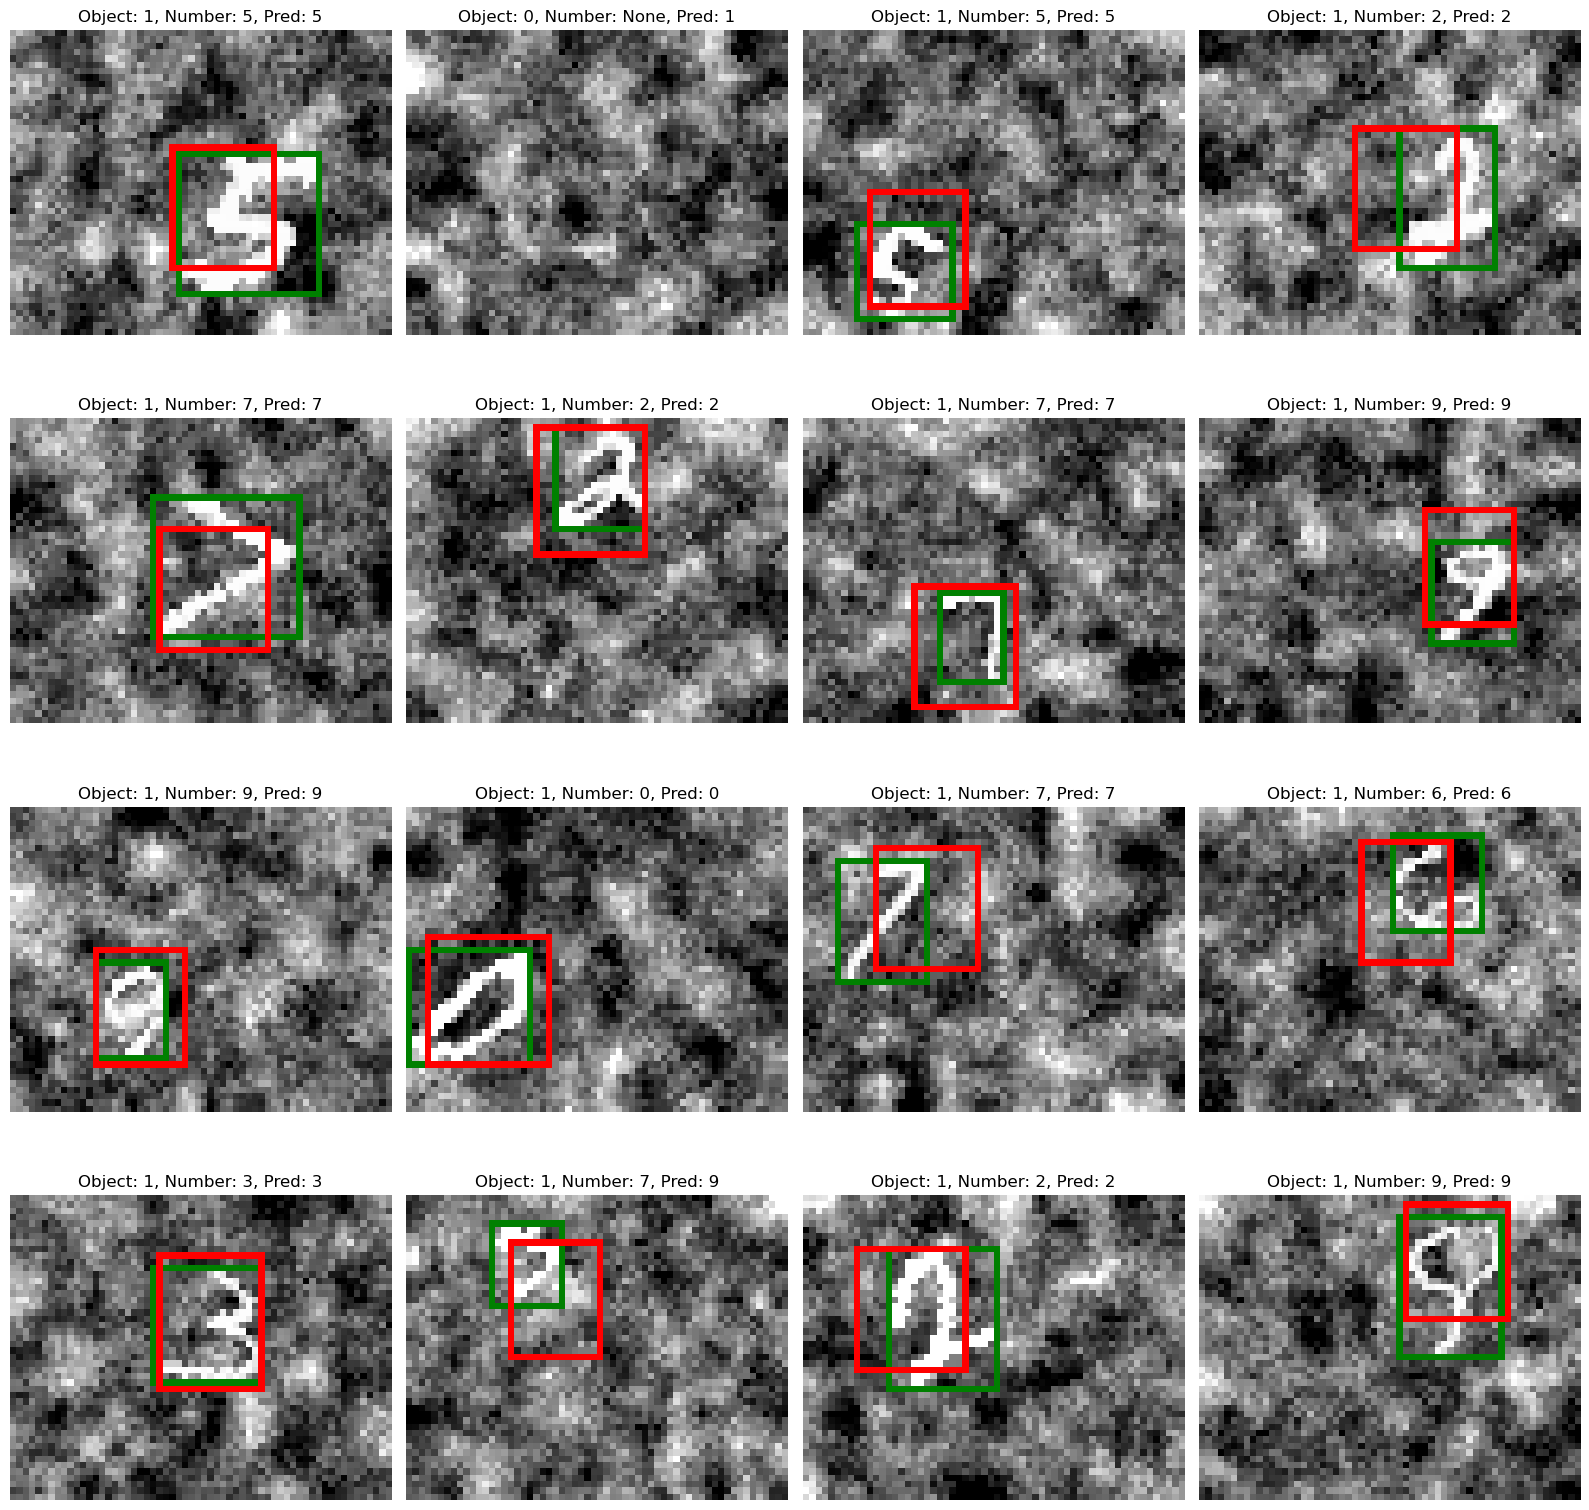

In [38]:
def show_samples(model, ds, preprocessor, n=7, device="cpu", display_ds=None, save_path=None):
    model.eval()

    images = ds.tensors[0][:n].to(device)

    with torch.no_grad():
        try:
            x = preprocessor(images)
        except TypeError:
            x = preprocessor(images, None)

        preds = model(x).cpu()

    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    for i in range(n):
        img, pc, pred_label, true_label = pred_vs_actual(ds, preds, i, display_ds=display_ds)

        axes[i].imshow(img)
        axes[i].set_title(f"Object: {pc}, Number: {true_label}, Pred: {pred_label}")
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

show_samples(best_model, norm_val, lambda x: x.to(device), n=16, device=device, display_ds=val, save_path="figures/validation_prediction_localization.png")


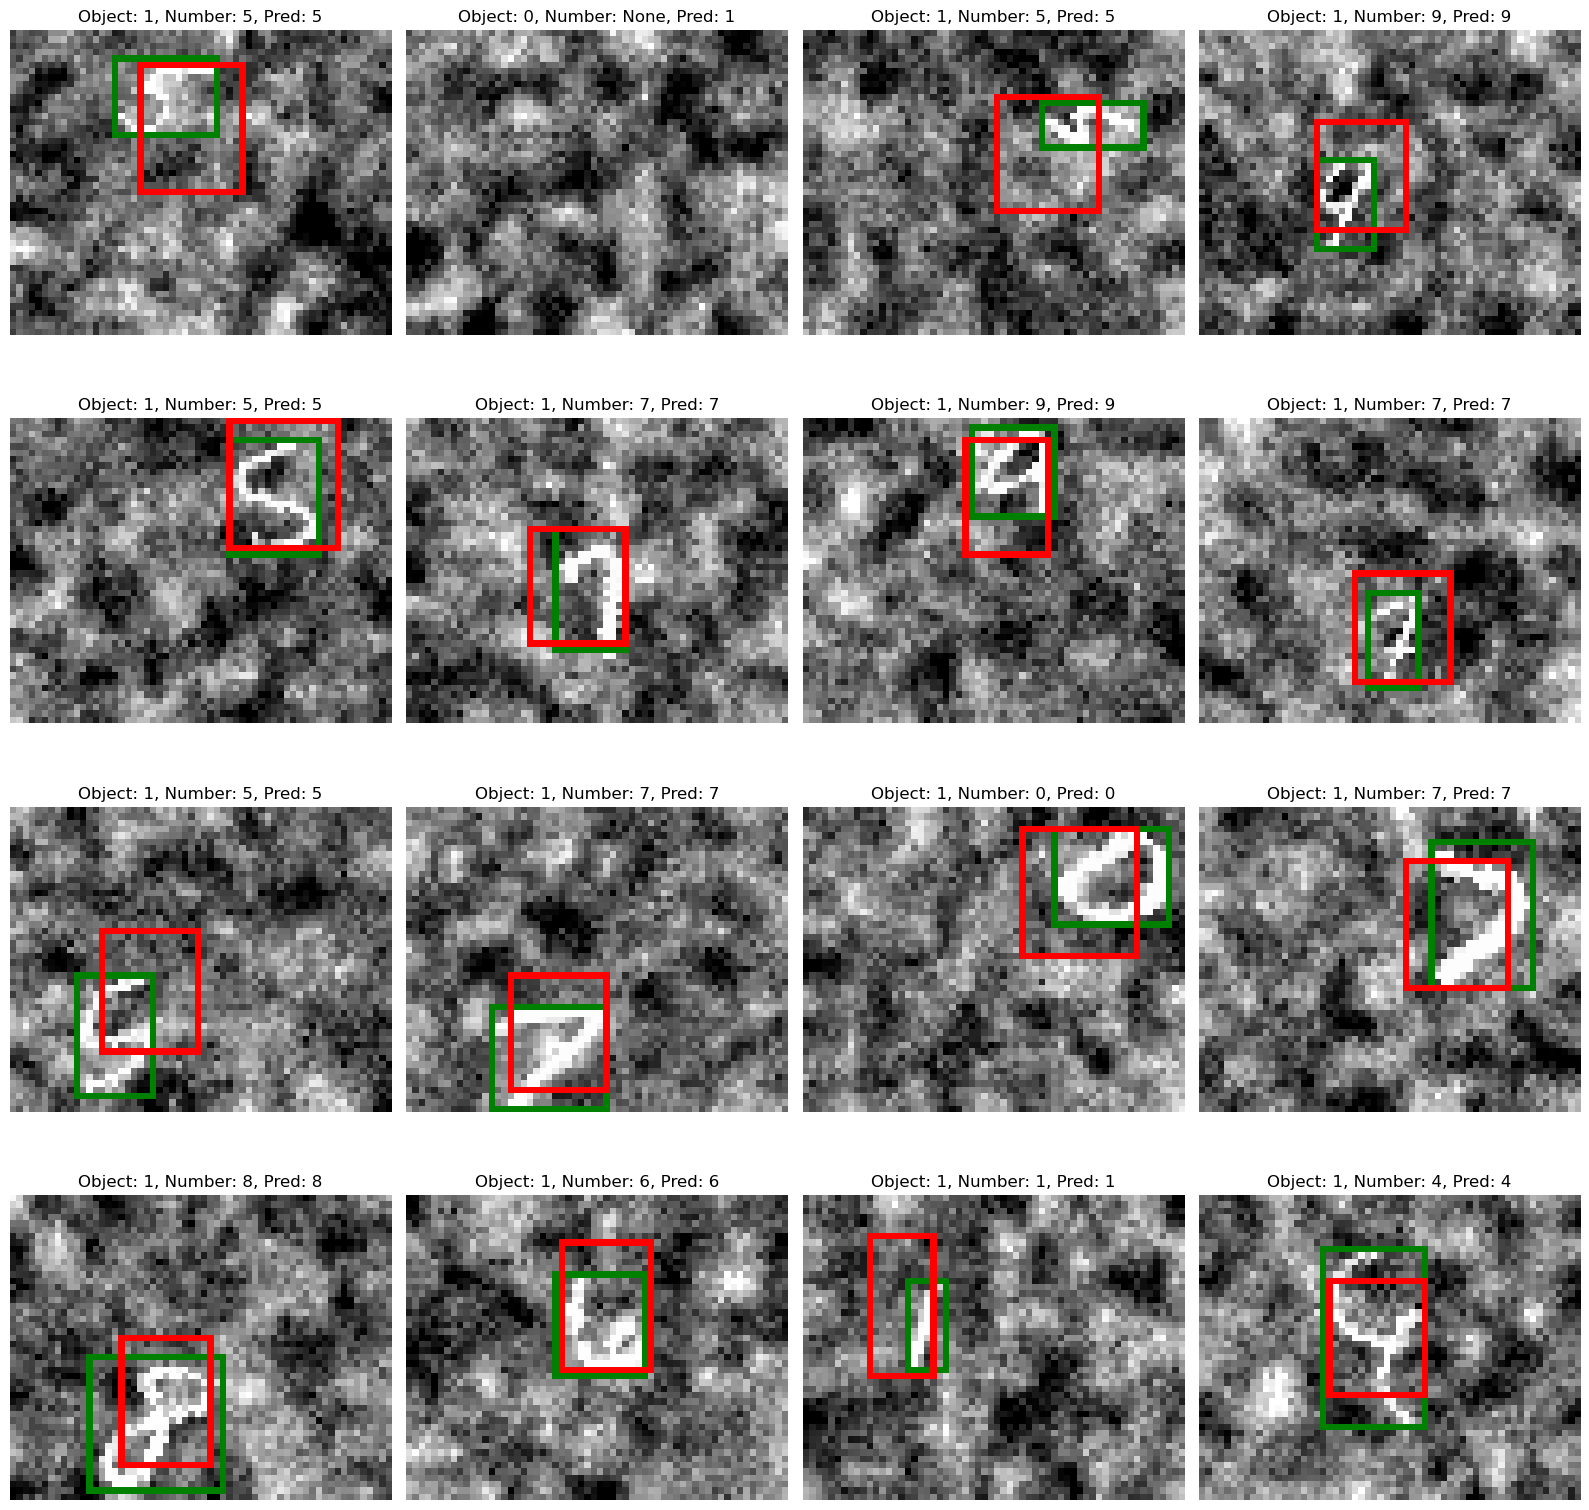

In [39]:
show_samples(best_model, norm_test, lambda x: x.to(device), n=16, device=device, display_ds=test, save_path="figures/test_prediction_localization.png")

In [40]:
test_loader = torch.utils.data.DataLoader(norm_test, batch_size=64, shuffle=False, num_workers=0)
_, test_acc, test_iou, test_perf = predict(best_model, test_loader)
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test IoU:         {test_iou:.4f}")
print(f"Test Performance: {test_perf:.4f}")

Test Accuracy:    0.8878
Test IoU:         0.4860
Test Performance: 0.6869
